# Relatório de exemplo

Notebook sintético, feito só para mostrar como o `paginar` imprime **tabela larga**,
**gráfico** e **texto** em uma folha A4 deitada. Os dados são gerados na hora, com
semente fixa, e não representam nada real.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
meses = pd.date_range('2025-01-01', periods=12, freq='MS').strftime('%Y-%m')

vendas = pd.DataFrame({
    'mes': meses,
    'unidades': rng.integers(800, 2000, 12),
    'preco_medio': rng.normal(49.9, 6, 12).round(2),
    'devolucoes': rng.integers(5, 90, 12),
    'clientes_novos': rng.integers(40, 300, 12),
}).set_index('mes')

vendas['receita'] = (vendas.unidades * vendas.preco_medio).round(2)
vendas['ticket'] = (vendas.receita / vendas.clientes_novos).round(2)
vendas['taxa_devolucao'] = (100 * vendas.devolucoes / vendas.unidades).round(2)
vendas

,unidades,preco_medio,devolucoes,clientes_novos,receita,ticket,taxa_devolucao
mes,,,,,,,
2025-01,907,50.67,77,216,45957.69,212.77,8.49
2025-02,1728,48.00,75,242,82944.00,342.74,4.34
2025-03,1585,49.80,28,237,78933.00,333.05,1.77
2025-04,1326,44.78,58,90,59378.28,659.76,4.37
2025-05,1319,55.18,19,134,72782.42,543.15,1.44
2025-06,1830,54.57,69,161,99863.10,620.27,3.77
2025-07,903,50.30,64,169,45420.90,268.76,7.09
2025-08,1636,56.66,35,51,92695.76,1817.56,2.14
2025-09,1041,52.71,10,182,54871.11,301.49,0.96


Uma tabela de sete colunas como essa é o caso que o Ctrl-P do navegador corta na
margem direita, seja no Colab, no Jupyter Lab ou no notebook aberto pelo VS Code.
Em A4 deitado, com a escala padrão de 0,8, ela cabe inteira.

In [2]:
resumo = vendas[['unidades', 'receita', 'ticket', 'taxa_devolucao']].agg(
    ['mean', 'std', 'min', 'max']).round(2)
print(resumo.to_string())

      unidades   receita   ticket  taxa_devolucao
mean   1382.42  69603.23   527.58            4.24
std     378.12  19869.75   430.54            2.78
min     903.00  40847.62   212.77            0.96
max    1970.00  99863.10  1817.56            9.53


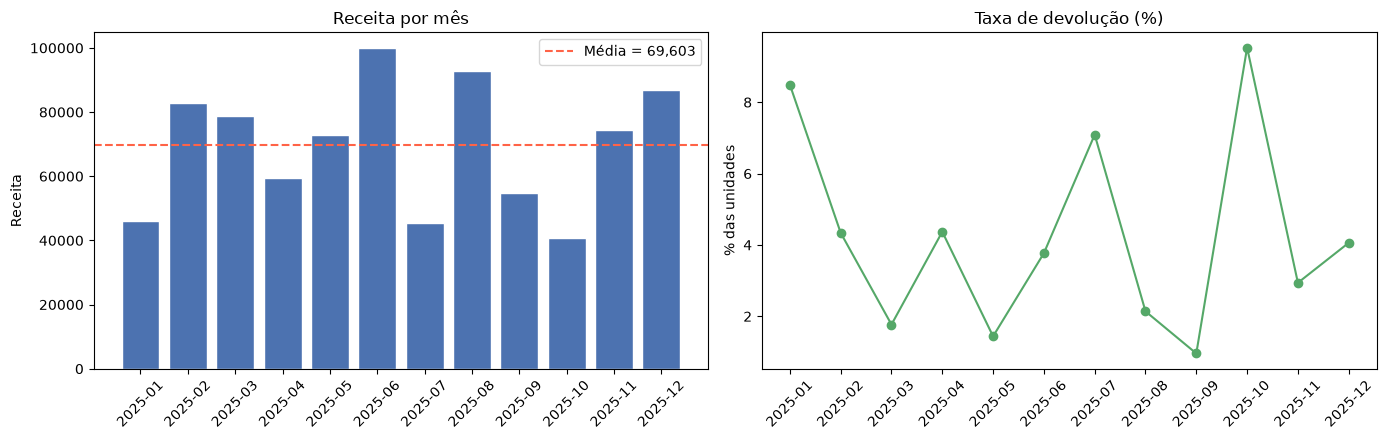

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(vendas.index, vendas.receita, color='#4C72B0', edgecolor='white')
axes[0].axhline(vendas.receita.mean(), color='tomato', linestyle='--',
                label=f'Média = {vendas.receita.mean():,.0f}')
axes[0].set_title('Receita por mês')
axes[0].set_ylabel('Receita')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].plot(vendas.index, vendas.taxa_devolucao, marker='o', color='#55A868')
axes[1].set_title('Taxa de devolução (%)')
axes[1].set_ylabel('% das unidades')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

O `paginar` evita quebrar figura e tabela no meio da página, então cada saída sai
inteira em uma folha só. O rodapé traz o título do notebook, que ele lê do primeiro
`#` do arquivo, e o número da página.